# 09 — TX90p vs TN90p: comparing neighbourhood rankings

Compares how neighbourhoods rank when heat exposure is measured by **TX90p** (daytime heat — daily maximum temperature exceeding its calendar-day 90th percentile) versus **TN90p** (overnight heat — daily minimum temperature exceeding its 90th percentile).

Three questions drive the analysis:

1. **Hazard:** do the same neighbourhoods have the most heat days and warm nights, or does the spatial pattern diverge?
2. **Person-days:** does the choice of metric change which neighbourhoods rank as highest aggregate burden?
3. **Priority consistency:** which neighbourhoods appear high-priority under *both* metrics — those are the most robust targets for intervention.

Absolute thresholds are not used here — TX90p and TN90p are the only metrics.

**Prerequisites:** `01_data_acquisition` (tmax), `01b_data_acquisition_tmin` (tmin), `02_compute_baselines` (TX90p threshold cache, population grids, neighbourhood boundaries).

## Setup

In [13]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import xarray as xr
from scipy.stats import spearmanr

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import (
    CITIES, load_city, load_city_tmin,
    load_tx90p_threshold, load_tn90p_threshold,
    compute_person_days_map,
    aggregate_to_neighbourhoods, aggregate_person_days_to_neighbourhoods,
    load_neighbourhood_boundaries,
)

DATA_DIR   = 'data'
DIAG_YEAR  = 2020
PERCENTILE = 90
CITY_KEYS  = ['salvador', 'teresina', 'caceres']

cities_tx, cities_tn = {}, {}
for c in CITY_KEYS:
    da = load_city(c, DATA_DIR)
    da.attrs['units'] = 'degC'
    cities_tx[c] = da
    da = load_city_tmin(c, DATA_DIR)
    da.attrs['units'] = 'degC'
    cities_tn[c] = da

thresh_tx = {c: load_tx90p_threshold(c, DATA_DIR) for c in CITY_KEYS}
thresh_tn = {c: load_tn90p_threshold(c, DATA_DIR) for c in CITY_KEYS}

gdfs = {c: load_neighbourhood_boundaries(c, DATA_DIR) for c in CITY_KEYS}

def load_pop_grid(city, year):
    return xr.open_dataset(f'{DATA_DIR}/{city}_pop_1km_{year}.nc')['population']

def count_doy_exceedances(da, thresh_doy):
    aligned = thresh_doy.sel(dayofyear=da.time.dt.dayofyear)
    return (da > aligned).resample(time='YS').sum(dim='time')

tx_annual, tn_annual = {}, {}
for c in CITY_KEYS:
    tx_t = thresh_tx[c].sel(percentile=PERCENTILE) if 'percentile' in thresh_tx[c].dims else thresh_tx[c]
    tn_t = thresh_tn[c].sel(percentile=PERCENTILE) if 'percentile' in thresh_tn[c].dims else thresh_tn[c]
    tx_annual[c] = count_doy_exceedances(cities_tx[c], tx_t)
    tn_annual[c] = count_doy_exceedances(cities_tn[c], tn_t)

salvador: shape {'time': 6497, 'lat': 55, 'lon': 67}  2003-01-01 to 2020-12-30
salvador: shape {'time': 6496, 'lat': 48, 'lon': 67}  2003-01-01 to 2020-12-30
teresina: shape {'time': 6497, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
teresina: shape {'time': 6496, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
caceres: shape {'time': 6497, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
caceres: shape {'time': 6496, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
salvador TX90p threshold: shape {'percentile': 2, 'lat': 55, 'lon': 67, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 26.0–73.7 °C
teresina TX90p threshold: shape {'percentile': 2, 'lat': 67, 'lon': 78, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 32.7–60.4 °C
caceres TX90p threshold: shape {'percentile': 2, 'lat': 89, 'lon': 89, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 30.9–43.9 °C
salvador TN90p threshold: shape {'percentile': 2, 'lat': 48, 'lon': 67, 'dayofyear': 365}  window=5  pe

In [14]:
def build_combined_table(city_key, year):
    """Per-neighbourhood table with TX90p and TN90p heat days, person-days, and ranks."""
    gdf      = gdfs[city_key]
    pop_grid = load_pop_grid(city_key, year)

    tx_hd = tx_annual[city_key].isel(
        time=(tx_annual[city_key].time.dt.year == year)
    ).squeeze('time')
    tn_hd = tn_annual[city_key].isel(
        time=(tn_annual[city_key].time.dt.year == year)
    ).squeeze('time')

    pop_nbhd   = aggregate_person_days_to_neighbourhoods(pop_grid, gdf, col='population')
    tx_hd_nbhd = aggregate_to_neighbourhoods(tx_hd, gdf, col='tx90p_hd')
    tn_hd_nbhd = aggregate_to_neighbourhoods(tn_hd, gdf, col='tn90p_hd')
    tx_pd_nbhd = aggregate_person_days_to_neighbourhoods(
        compute_person_days_map(tx_hd, pop_grid), gdf, col='tx90p_pd')
    tn_pd_nbhd = aggregate_person_days_to_neighbourhoods(
        compute_person_days_map(tn_hd, pop_grid), gdf, col='tn90p_pd')

    df = gdf[['name']].copy()
    df['population'] = pop_nbhd['population'].values
    df['tx90p_hd']   = tx_hd_nbhd['tx90p_hd'].values
    df['tn90p_hd']   = tn_hd_nbhd['tn90p_hd'].values
    df['tx90p_pd']   = tx_pd_nbhd['tx90p_pd'].values
    df['tn90p_pd']   = tn_pd_nbhd['tn90p_pd'].values
    for col in ['population', 'tx90p_hd', 'tn90p_hd', 'tx90p_pd', 'tn90p_pd']:
        df[f'rank_{col}'] = df[col].rank(ascending=False, method='min').astype(int)
    return df.dropna().reset_index(drop=True)

tables = {c: build_combined_table(c, DIAG_YEAR) for c in CITY_KEYS}

table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th', 'props': 'text-align:center; white-space:nowrap; font-size:0.85em;'},
    {'selector': 'td', 'props': 'text-align:center; font-size:0.85em;'},
]

for c in CITY_KEYS:
    df = tables[c]
    rho, _ = spearmanr(df['tx90p_hd'], df['tn90p_hd'])
    print(f"{CITIES[c]['label']:25s}  {len(df):3d} neighbourhoods  "
          f"TX90p hd {df['tx90p_hd'].min():.0f}\u2013{df['tx90p_hd'].max():.0f} days  "
          f"TN90p hd {df['tn90p_hd'].min():.0f}\u2013{df['tn90p_hd'].max():.0f} nights  "
          f"\u03c1(TX,TN) hd = {rho:+.3f}")

Salvador, Brazil            22 neighbourhoods  TX90p hd 0–12 days  TN90p hd 0–25 nights  ρ(TX,TN) hd = +0.822
Teresina, Brazil           112 neighbourhoods  TX90p hd 4–10 days  TN90p hd 8–30 nights  ρ(TX,TN) hd = +0.059
Cáceres, Brazil             43 neighbourhoods  TX90p hd 122–134 days  TN90p hd 45–62 nights  ρ(TX,TN) hd = -0.452


## 1 — Hazard: TX90p heat days vs TN90p warm nights

TX90p and TN90p are correlated by construction — both are driven by the same weather patterns — but they need not rank the same neighbourhoods identically.  Daytime maxima are more strongly influenced by surface properties (impervious cover, shade, albedo), while overnight minima are more influenced by atmospheric moisture and long-wave re-emission.  Where the two diverge, the neighbourhood's thermal character differs between day and night.

The maps below show the spatial pattern of each metric.  The scatter plots show whether the *ranking* of neighbourhoods is consistent.

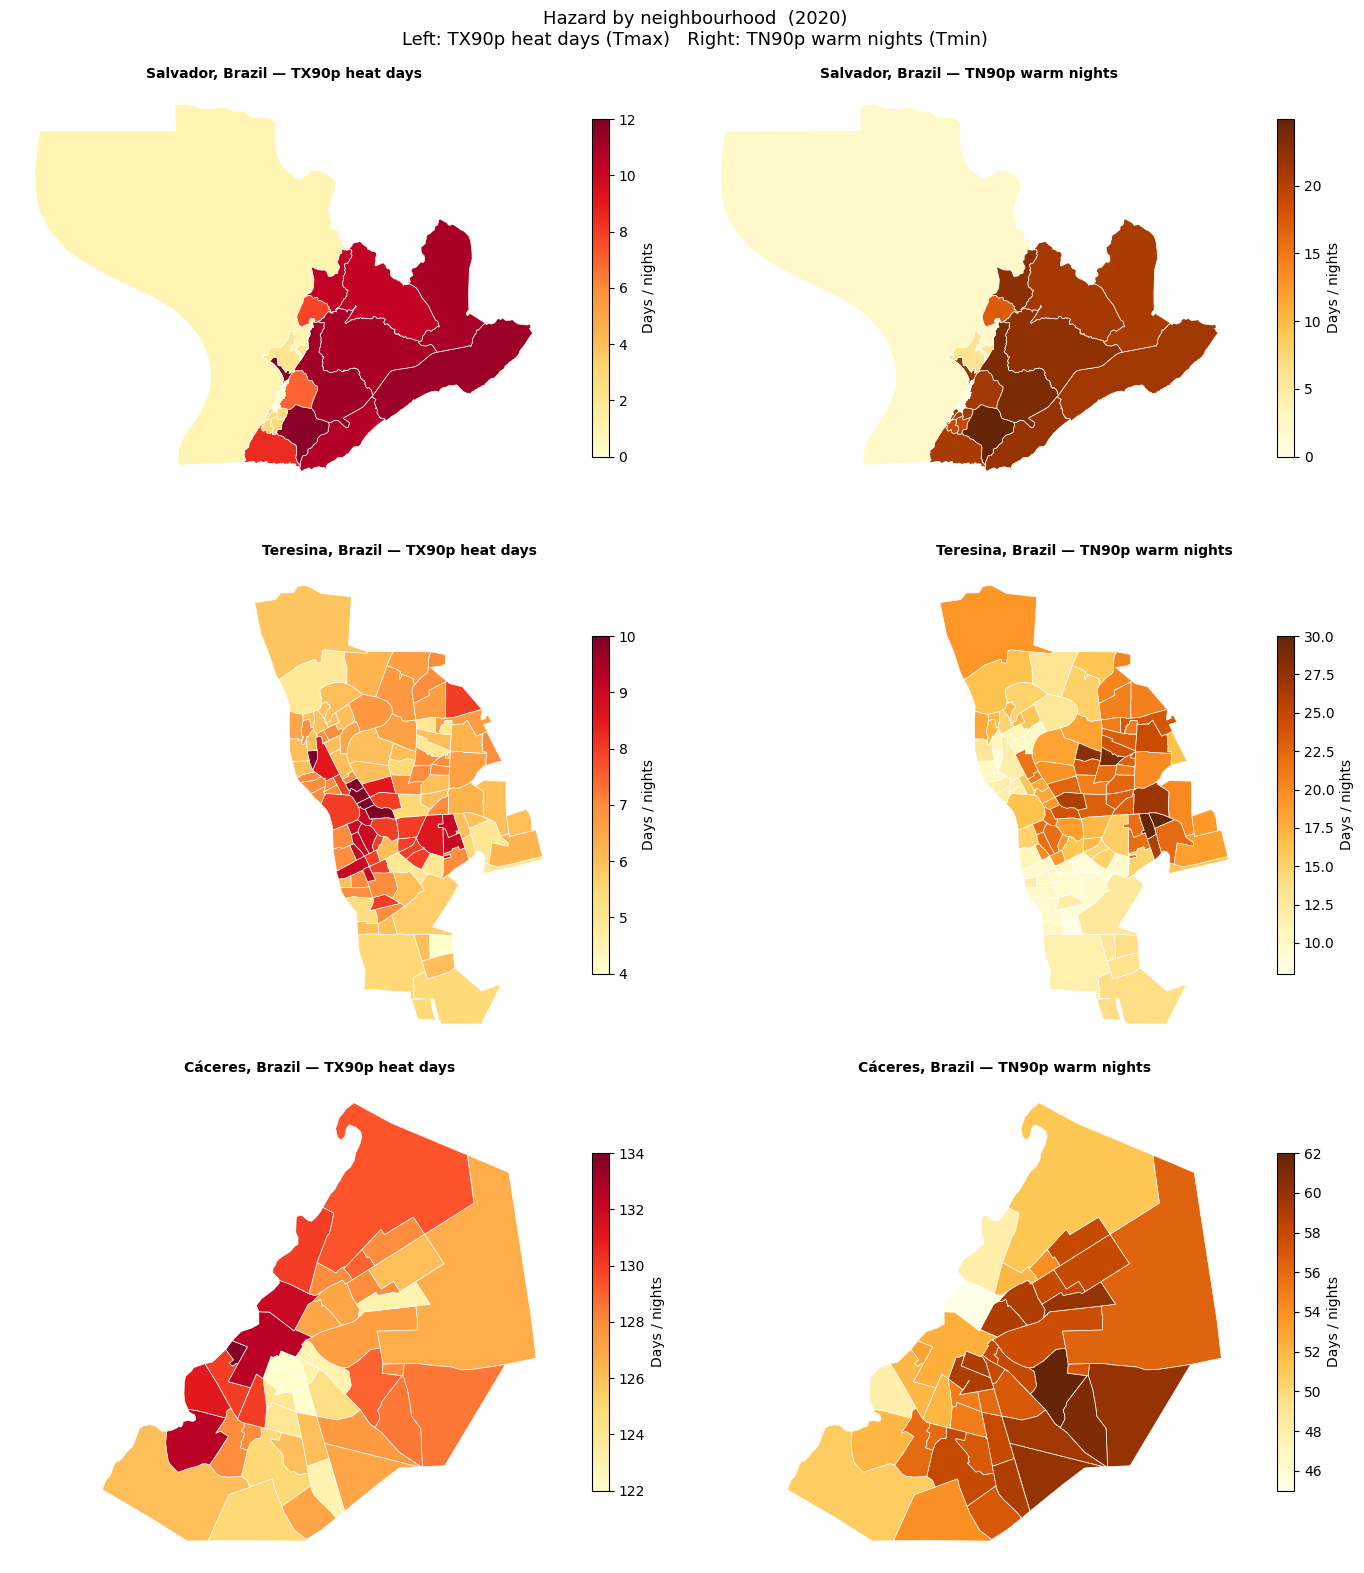

In [15]:
# ---- Choropleth maps: TX90p heat days vs TN90p warm nights ------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle(
    f'Hazard by neighbourhood  ({DIAG_YEAR})\n'
    'Left: TX90p heat days (Tmax)   Right: TN90p warm nights (Tmin)',
    fontsize=13,
)

for row, c in enumerate(CITY_KEYS):
    df    = tables[c]
    label = CITIES[c]['label']
    plot_gdf = gdfs[c].merge(df[['name', 'tx90p_hd', 'tn90p_hd']], on='name', how='left')

    for col, (col_name, title_suffix, cmap) in enumerate([
        ('tx90p_hd', 'TX90p heat days',   'YlOrRd'),
        ('tn90p_hd', 'TN90p warm nights', 'YlOrBr'),
    ]):
        ax = axes[row][col]
        plot_gdf.plot(
            column=col_name, ax=ax, cmap=cmap,
            legend=True,
            legend_kwds={'label': 'Days / nights', 'shrink': 0.7},
            edgecolor='white', linewidth=0.5,
            missing_kwds={'color': 'lightgrey'},
        )
        ax.set_title(f'{label} \u2014 {title_suffix}', fontsize=10, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

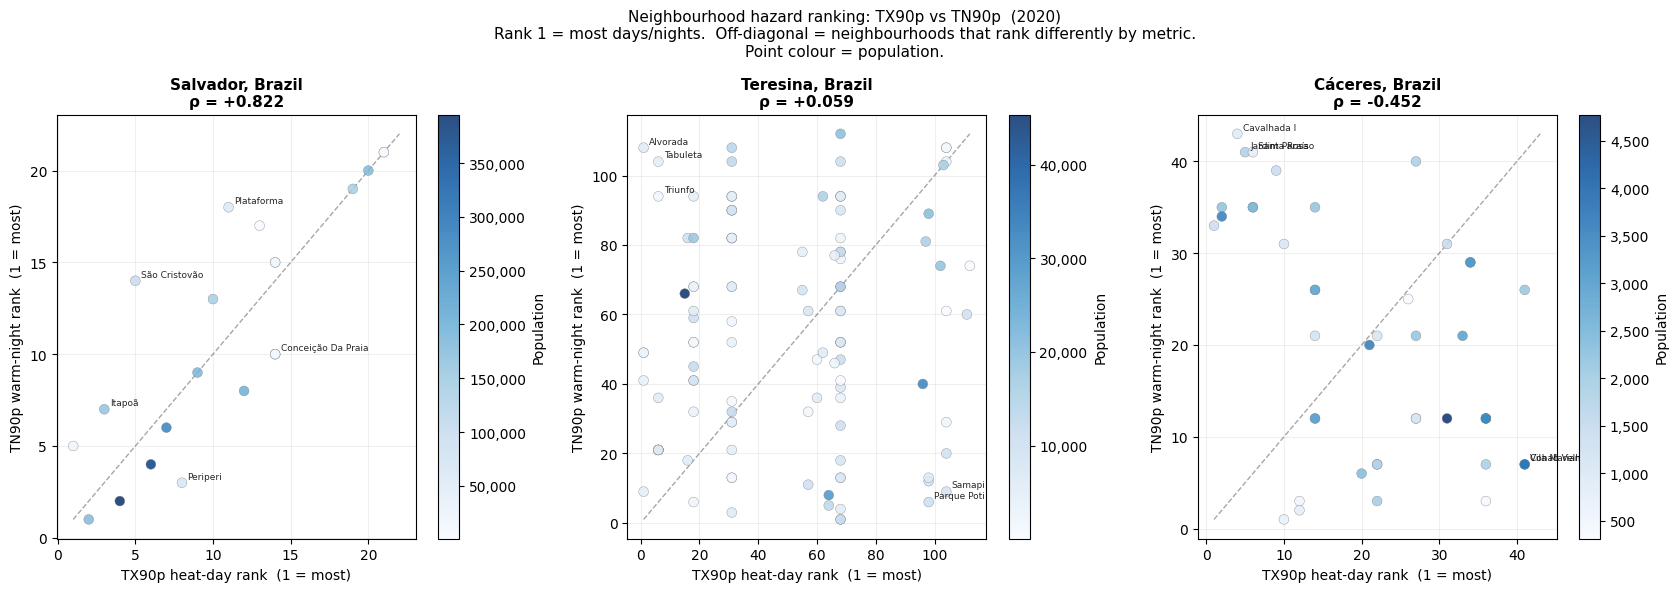


Median absolute hazard rank shift (TX90p → TN90p):
  Salvador, Brazil           median shift = 2.5 places  max shift = 9 places  ρ = +0.822
  Teresina, Brazil           median shift = 28.5 places  max shift = 107 places  ρ = +0.059
  Cáceres, Brazil            median shift = 15.0 places  max shift = 39 places  ρ = -0.452


In [16]:
# ---- Hazard rank scatter: TX90p rank vs TN90p rank --------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle(
    f'Neighbourhood hazard ranking: TX90p vs TN90p  ({DIAG_YEAR})\n'
    'Rank 1 = most days/nights.  Off-diagonal = neighbourhoods that rank differently by metric.\n'
    'Point colour = population.',
    fontsize=11,
)

for ax, c in zip(axes, CITY_KEYS):
    df    = tables[c]
    n     = len(df)
    label = CITIES[c]['label']
    rho, _ = spearmanr(df['rank_tx90p_hd'], df['rank_tn90p_hd'])
    shift   = (df['rank_tx90p_hd'] - df['rank_tn90p_hd']).abs()

    sc = ax.scatter(
        df['rank_tx90p_hd'], df['rank_tn90p_hd'],
        c=df['population'], cmap='Blues',
        s=50, alpha=0.85, edgecolors='grey', linewidth=0.3, zorder=3,
    )
    plt.colorbar(sc, ax=ax, label='Population',
                 format=mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # Label top movers
    top_movers = shift.nlargest(5).index
    for idx in top_movers:
        row = df.loc[idx]
        ax.annotate(row['name'], (row['rank_tx90p_hd'], row['rank_tn90p_hd']),
                    fontsize=6.5, xytext=(4, 3), textcoords='offset points', alpha=0.85)

    ax.plot([1, n], [1, n], 'k--', lw=1, alpha=0.35)
    ax.set_xlabel('TX90p heat-day rank  (1 = most)', fontsize=10)
    ax.set_ylabel('TN90p warm-night rank  (1 = most)', fontsize=10)
    ax.set_title(f'{label}\n\u03c1 = {rho:+.3f}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Hazard rank-shift summary
print(f'\nMedian absolute hazard rank shift (TX90p \u2192 TN90p):')
for c in CITY_KEYS:
    df = tables[c]
    shift = (df['rank_tx90p_hd'] - df['rank_tn90p_hd']).abs()
    rho, _ = spearmanr(df['rank_tx90p_hd'], df['rank_tn90p_hd'])
    print(f'  {CITIES[c]["label"]:25s}  median shift = {shift.median():.1f} places  '
          f'max shift = {shift.max():.0f} places  \u03c1 = {rho:+.3f}')

## 2 — Person-days: does metric choice change who ranks highest?

Person-days (TX90p) and person-nights (TN90p) weight heat exposure by population.  As shown in notebooks 07 and 07b, both products tend to reflect population distribution at 1 km resolution.  The question here is whether the *residual* variation — the part not explained by population — differs enough between TX90p and TN90p to change neighbourhood priority rankings.

A high rank correlation between TX90p person-days and TN90p person-nights means the same neighbourhoods rank as high burden under both metrics; a lower correlation means the metric choice matters for prioritisation.

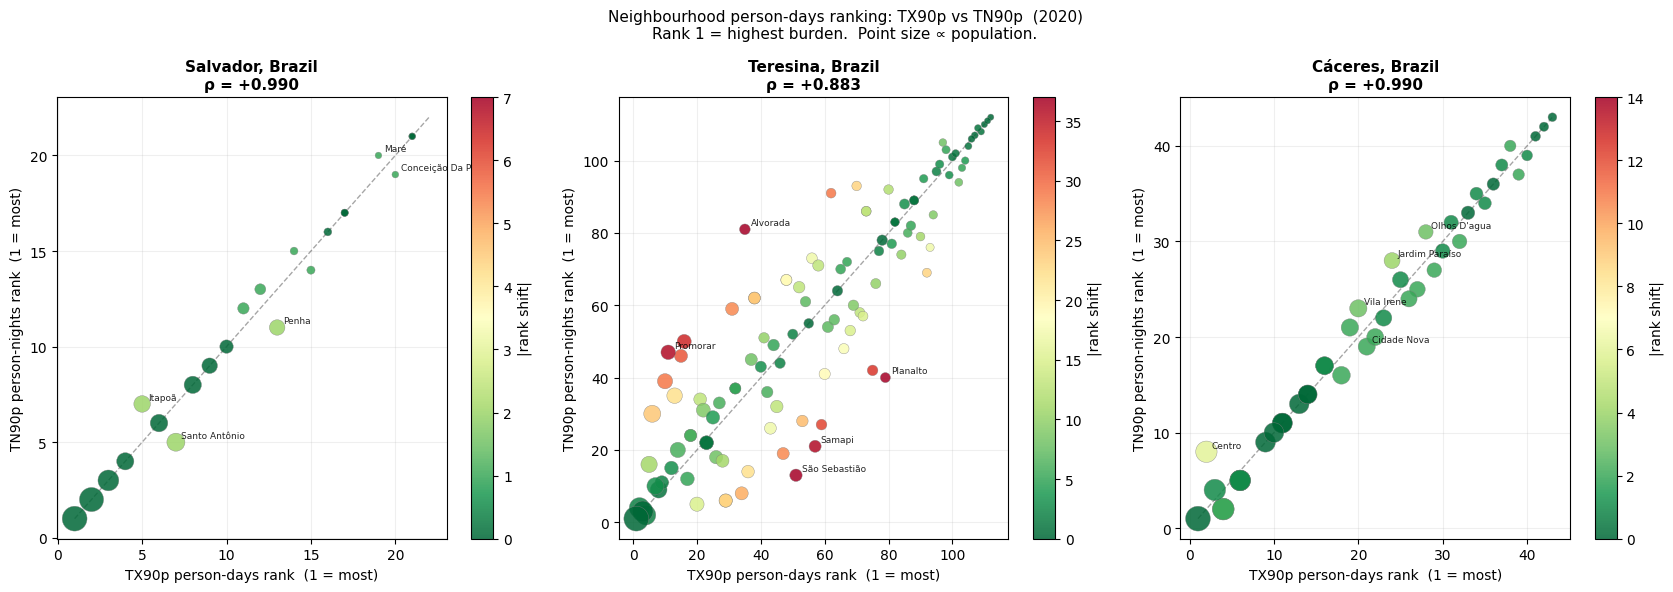

In [17]:
# ---- Person-days rank scatter: TX90p vs TN90p --------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle(
    f'Neighbourhood person-days ranking: TX90p vs TN90p  ({DIAG_YEAR})\n'
    'Rank 1 = highest burden.  Point size \u221d population.',
    fontsize=11,
)

for ax, c in zip(axes, CITY_KEYS):
    df    = tables[c]
    n     = len(df)
    label = CITIES[c]['label']
    rho, _ = spearmanr(df['rank_tx90p_pd'], df['rank_tn90p_pd'])
    shift   = (df['rank_tx90p_pd'] - df['rank_tn90p_pd']).abs()
    pop_s   = (df['population'] / df['population'].max()) * 300 + 20

    sc = ax.scatter(
        df['rank_tx90p_pd'], df['rank_tn90p_pd'],
        s=pop_s, c=shift, cmap='RdYlGn_r',
        vmin=0, vmax=max(n // 3, 1),
        alpha=0.85, edgecolors='grey', linewidth=0.3, zorder=3,
    )
    plt.colorbar(sc, ax=ax, label='|rank shift|')

    top_movers = shift.nlargest(5).index
    for idx in top_movers:
        row = df.loc[idx]
        ax.annotate(row['name'], (row['rank_tx90p_pd'], row['rank_tn90p_pd']),
                    fontsize=6.5, xytext=(4, 3), textcoords='offset points', alpha=0.85)

    ax.plot([1, n], [1, n], 'k--', lw=1, alpha=0.35)
    ax.set_xlabel('TX90p person-days rank  (1 = most)', fontsize=10)
    ax.set_ylabel('TN90p person-nights rank  (1 = most)', fontsize=10)
    ax.set_title(f'{label}\n\u03c1 = {rho:+.3f}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [18]:
# ---- Largest person-days rank movers ----------------------------------------
print(f'Largest rank shifts: TX90p person-days \u2192 TN90p person-nights  ({DIAG_YEAR})')
print('Positive shift = neighbourhood ranks HIGHER under TN90p than TX90p\n')

for c in CITY_KEYS:
    df = tables[c].copy()
    df['pd_rank_shift'] = df['rank_tx90p_pd'] - df['rank_tn90p_pd']
    df['hd_rank_shift'] = df['rank_tx90p_hd'] - df['rank_tn90p_hd']

    cols = ['name', 'population', 'tx90p_hd', 'tn90p_hd',
            'rank_tx90p_pd', 'rank_tn90p_pd', 'pd_rank_shift']
    movers = pd.concat([
        df.nlargest(5,  'pd_rank_shift'),
        df.nsmallest(5, 'pd_rank_shift'),
    ])[cols].rename(columns={
        'name': 'Name', 'population': 'Pop',
        'tx90p_hd': 'TX hd', 'tn90p_hd': 'TN hd',
        'rank_tx90p_pd': 'TX pd rank', 'rank_tn90p_pd': 'TN pd rank',
        'pd_rank_shift': 'Shift',
    })
    print(f'--- {CITIES[c]["label"]} ---')
    display(
        movers.reset_index(drop=True).style
        .format({'Pop': '{:,.0f}', 'TX hd': '{:.1f}', 'TN hd': '{:.1f}', 'Shift': '{:+d}'})
        .bar(subset=['Shift'], align='zero', color=['#d65f5f', '#5fba7d'])
    )

Largest rank shifts: TX90p person-days → TN90p person-nights  (2020)
Positive shift = neighbourhood ranks HIGHER under TN90p than TX90p

--- Salvador, Brazil ---


,Name,Pop,TX hd,TN hd,TX pd rank,TN pd rank,Shift
0,Santo Antônio,"195,988",7.0,21.1,7,5,+2
1,Penha,"137,448",2.1,6.3,13,11,+2
2,Conceição Da Praia,"4,688",3.0,21.0,20,19,+1
3,Santana,"19,484",3.0,19.0,15,14,+1
4,Amaralina,"270,322",10.7,21.9,3,3,+0
5,Itapoã,"161,716",11.3,21.2,5,7,-2
6,Maré,"3,361",6.9,17.2,19,20,-1
7,Mares,"15,114",12.0,22.0,14,15,-1
8,Periperi,"63,194",10.4,22.5,11,12,-1
9,Plataforma,"55,646",7.8,17.2,12,13,-1


--- Teresina, Brazil ---


,Name,Pop,TX hd,TN hd,TX pd rank,TN pd rank,Shift
0,Planalto,"4,927",6.0,28.0,79,40,+39
1,São Sebastião,"9,074",5.0,22.2,51,13,+38
2,Samapi,"8,463",5.0,24.0,57,21,+36
3,São João,"5,785",5.5,23.0,75,42,+33
4,Piçarreira,"5,955",7.0,29.0,59,27,+32
5,Alvorada,"5,963",10.0,9.0,35,81,-46
6,Promorar,"13,651",7.0,9.0,11,47,-36
7,Lourival Parente,"12,588",7.0,9.5,16,50,-34
8,Aeroporto,"10,446",8.5,12.0,15,46,-31
9,Água Mineral,"15,104",6.5,10.0,10,39,-29


--- Cáceres, Brazil ---


,Name,Pop,TX hd,TN hd,TX pd rank,TN pd rank,Shift
0,Cidade Nova,"2,110",126.0,57.0,21,19,+2
1,Vila Real,"1,438",125.0,54.0,32,30,+2
2,Santa Izabel,"2,068",122.0,56.0,22,20,+2
3,Vila Mariana,"3,553",122.0,59.0,4,2,+2
4,Cohab Velha,"3,553",122.0,59.0,4,2,+2
5,Centro,"3,454",132.5,52.5,2,8,-6
6,Jardim Paraíso,"1,783",131.0,48.0,24,28,-4
7,Vila Irene,"2,155",128.0,52.0,20,23,-3
8,Olhos D'agua,"1,430",129.4,51.3,28,31,-3
9,Jardim Imperial,"2,174",132.5,52.0,19,21,-2


## 3 — Priority consistency: which neighbourhoods rank high on both metrics?

Neighbourhoods in the top half of *both* TX90p and TN90p person-days rankings face sustained heat exposure across the full diurnal cycle — daytime heat with no overnight recovery.  These are the most robustly high-priority neighbourhoods regardless of which metric is used.

The scatter below places each neighbourhood in a two-dimensional priority space.  The quadrant boundary is the **city median** for each metric.  Colour indicates which quadrant a neighbourhood occupies:

| Colour | Quadrant | Interpretation |
|--------|----------|----------------|
| Red | High TX90p + High TN90p | Both metrics agree: highest burden |
| Orange | High TX90p only | Daytime priority; nights cooler than median |
| Blue | High TN90p only | Overnight priority; days cooler than median |
| Grey | Neither | Below median on both |

Point size is proportional to population.

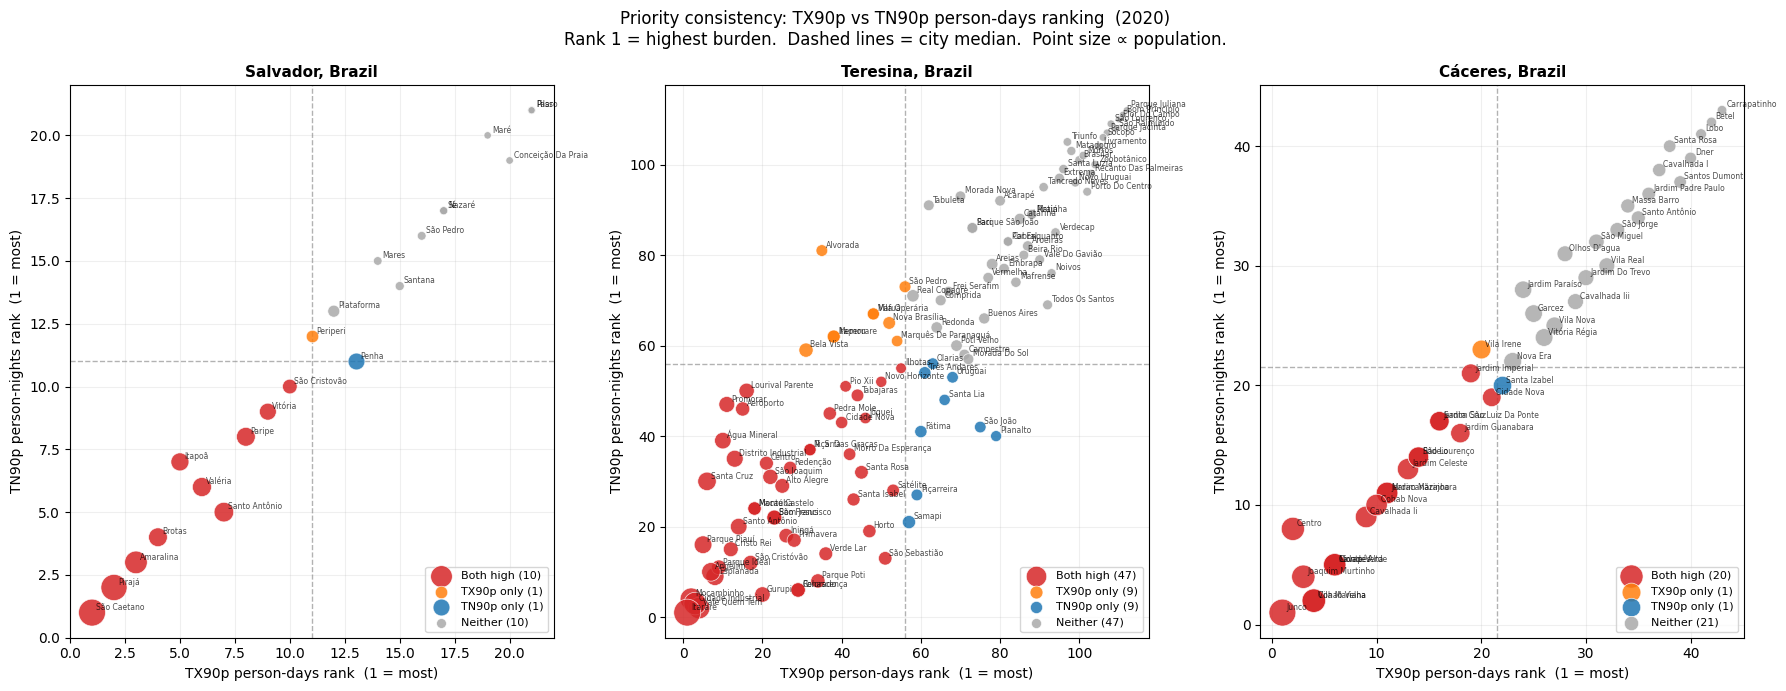

In [19]:
PRIORITY_COLORS = {
    'Both high':     '#d62728',
    'TX90p only':    '#ff7f0e',
    'TN90p only':    '#1f77b4',
    'Neither':       '#aaaaaa',
}

def assign_priority(tx_rank, tn_rank, n):
    """Top half = rank <= n/2  (lower rank number = higher burden)."""
    tx_high = tx_rank <= n / 2
    tn_high = tn_rank <= n / 2
    if tx_high and tn_high: return 'Both high'
    if tx_high:             return 'TX90p only'
    if tn_high:             return 'TN90p only'
    return 'Neither'

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle(
    f'Priority consistency: TX90p vs TN90p person-days ranking  ({DIAG_YEAR})\n'
    'Rank 1 = highest burden.  Dashed lines = city median.  Point size \u221d population.',
    fontsize=12,
)

for ax, c in zip(axes, CITY_KEYS):
    df    = tables[c].copy()
    n     = len(df)
    label = CITIES[c]['label']
    pop_s = (df['population'] / df['population'].max()) * 350 + 25

    df['priority'] = df.apply(
        lambda r: assign_priority(r['rank_tx90p_pd'], r['rank_tn90p_pd'], n), axis=1
    )

    for cat, color in PRIORITY_COLORS.items():
        mask = df['priority'] == cat
        ax.scatter(
            df.loc[mask, 'rank_tx90p_pd'],
            df.loc[mask, 'rank_tn90p_pd'],
            s=pop_s[mask], color=color, alpha=0.85,
            edgecolors='white', linewidth=0.5,
            label=f'{cat} ({mask.sum()})', zorder=3,
        )

    # Label all neighbourhoods
    for _, row in df.iterrows():
        ax.annotate(row['name'], (row['rank_tx90p_pd'], row['rank_tn90p_pd']),
                    fontsize=5.5, alpha=0.7, xytext=(3, 2), textcoords='offset points')

    ax.axvline(n / 2, color='grey', linewidth=1, linestyle='--', alpha=0.6)
    ax.axhline(n / 2, color='grey', linewidth=1, linestyle='--', alpha=0.6)
    ax.set_xlabel('TX90p person-days rank  (1 = most)', fontsize=10)
    ax.set_ylabel('TN90p person-nights rank  (1 = most)', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [20]:
# ---- Summary table: priority classification per city ------------------------
print(f'Priority classification summary  ({DIAG_YEAR})\n')

for c in CITY_KEYS:
    df = tables[c].copy()
    n  = len(df)
    df['priority'] = df.apply(
        lambda r: assign_priority(r['rank_tx90p_pd'], r['rank_tn90p_pd'], n), axis=1
    )

    summary = df.groupby('priority').agg(
        n_neighbourhoods=('name', 'count'),
        total_population=('population', 'sum'),
        mean_tx90p_hd=('tx90p_hd', 'mean'),
        mean_tn90p_hd=('tn90p_hd', 'mean'),
        total_tx90p_pd=('tx90p_pd', 'sum'),
        total_tn90p_pd=('tn90p_pd', 'sum'),
    ).reindex(PRIORITY_COLORS.keys()).fillna(0)

    summary.index.name = 'Priority category'
    summary.columns = [
        'N', 'Total population',
        'Mean TX90p hd', 'Mean TN90p hd',
        'Total TX90p pd', 'Total TN90p pd',
    ]

    rho_pd, _ = spearmanr(df['rank_tx90p_pd'], df['rank_tn90p_pd'])
    rho_hd, _ = spearmanr(df['rank_tx90p_hd'], df['rank_tn90p_hd'])
    pct_both  = 100 * (df['priority'] == 'Both high').sum() / n

    print(f'--- {CITIES[c]["label"]} ---'
          f'  \u03c1(TX pd, TN pd) = {rho_pd:+.3f}'
          f'  \u03c1(TX hd, TN hd) = {rho_hd:+.3f}'
          f'  {pct_both:.0f}% of neighbourhoods high-priority on both')
    display(
        summary.style
        .format({
            'N': '{:.0f}',
            'Total population': '{:,.0f}',
            'Mean TX90p hd': '{:.1f}',
            'Mean TN90p hd': '{:.1f}',
            'Total TX90p pd': '{:,.0f}',
            'Total TN90p pd': '{:,.0f}',
        })
        .bar(subset=['Total TX90p pd', 'Total TN90p pd'], color='#e07b39', vmin=0)
        .set_table_styles(table_styles)
    )
    print()

Priority classification summary  (2020)

--- Salvador, Brazil ---  ρ(TX pd, TN pd) = +0.990  ρ(TX hd, TN hd) = +0.822  45% of neighbourhoods high-priority on both


,N,Total population,Mean TX90p hd,Mean TN90p hd,Total TX90p pd,Total TN90p pd
Priority category,,,,,,
Both high,10,"2,171,632",9.3,20.0,"22,148,852","47,417,035"
TX90p only,1,"63,194",10.4,22.5,"564,834","1,349,849"
TN90p only,1,"137,448",2.1,6.3,"445,397","1,418,163"
Neither,10,"142,554",4.2,15.7,"863,524","2,641,517"



--- Teresina, Brazil ---  ρ(TX pd, TN pd) = +0.883  ρ(TX hd, TN hd) = +0.059  42% of neighbourhoods high-priority on both


,N,Total population,Mean TX90p hd,Mean TN90p hd,Total TX90p pd,Total TN90p pd
Priority category,,,,,,
Both high,47,"593,306",6.9,18.6,"4,046,699","10,422,732"
TX90p only,9,"65,112",7.2,11.4,"461,450","730,293"
TN90p only,9,"55,765",6.2,22.3,"337,797","1,228,645"
Neither,47,"143,832",6.9,15.4,"993,822","2,099,139"



--- Cáceres, Brazil ---  ρ(TX pd, TN pd) = +0.990  ρ(TX hd, TN hd) = -0.452  47% of neighbourhoods high-priority on both


,N,Total population,Mean TX90p hd,Mean TN90p hd,Total TX90p pd,Total TN90p pd
Priority category,,,,,,
Both high,20,"59,374",126.4,56.4,"7,474,920","3,362,534"
TX90p only,1,"2,155",128.0,52.0,"275,831","112,056"
TN90p only,1,"2,068",122.0,56.0,"252,295","115,808"
Neither,21,"24,790",127.8,55.7,"3,164,490","1,374,072"


## 4 — Bump charts: how neighbourhood rankings shift between TN90p and TX90p

Each chart shows the full ranked list for one city.  Left axis = TN90p person-nights rank, right axis = TX90p person-days rank.  Lines connect each neighbourhood between its two positions.

Line colour encodes the magnitude of the rank shift — grey lines mean the neighbourhood sits in roughly the same place under both metrics; red lines are the biggest movers.  The top 5 neighbourhoods on each side and the 5 largest movers are labelled.

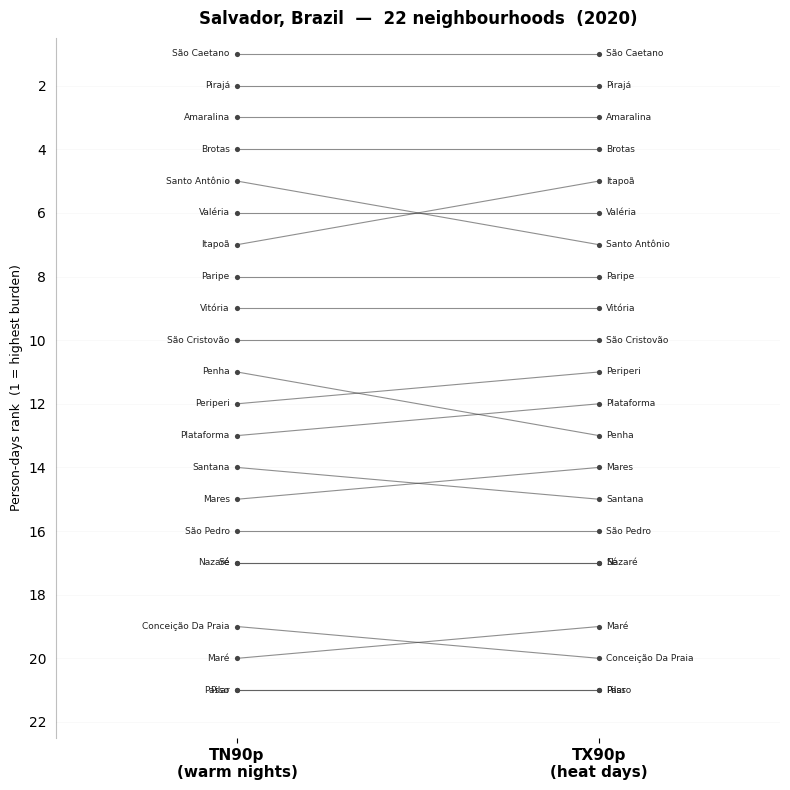

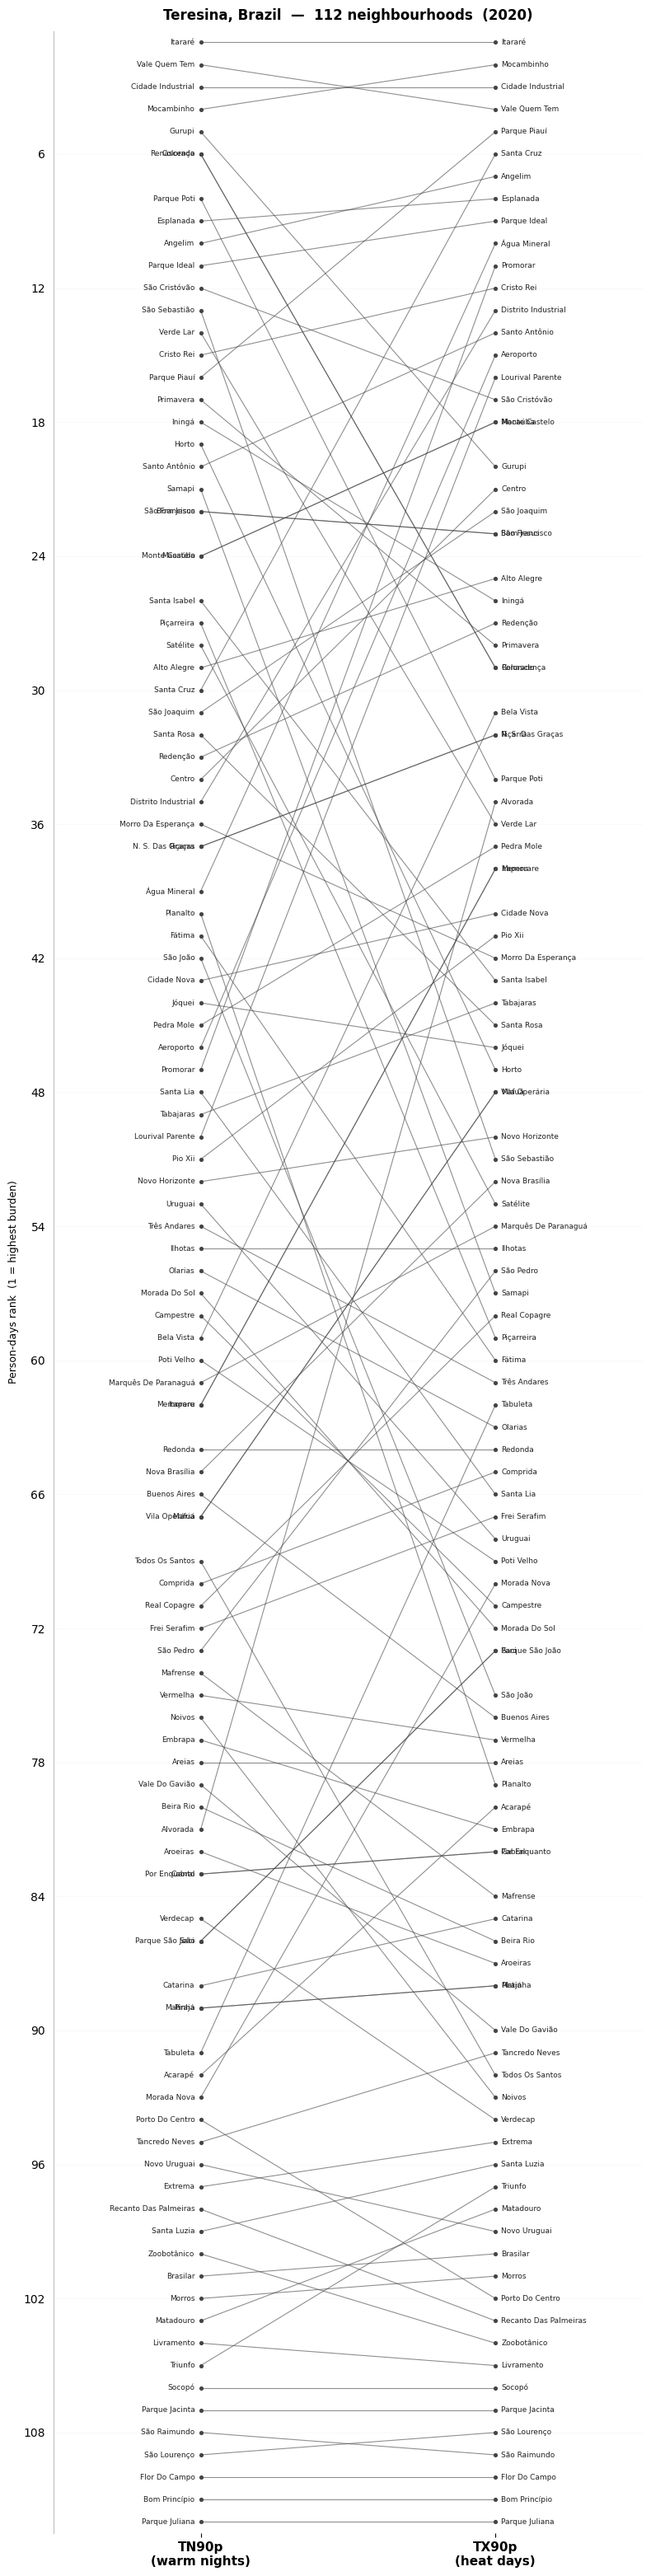

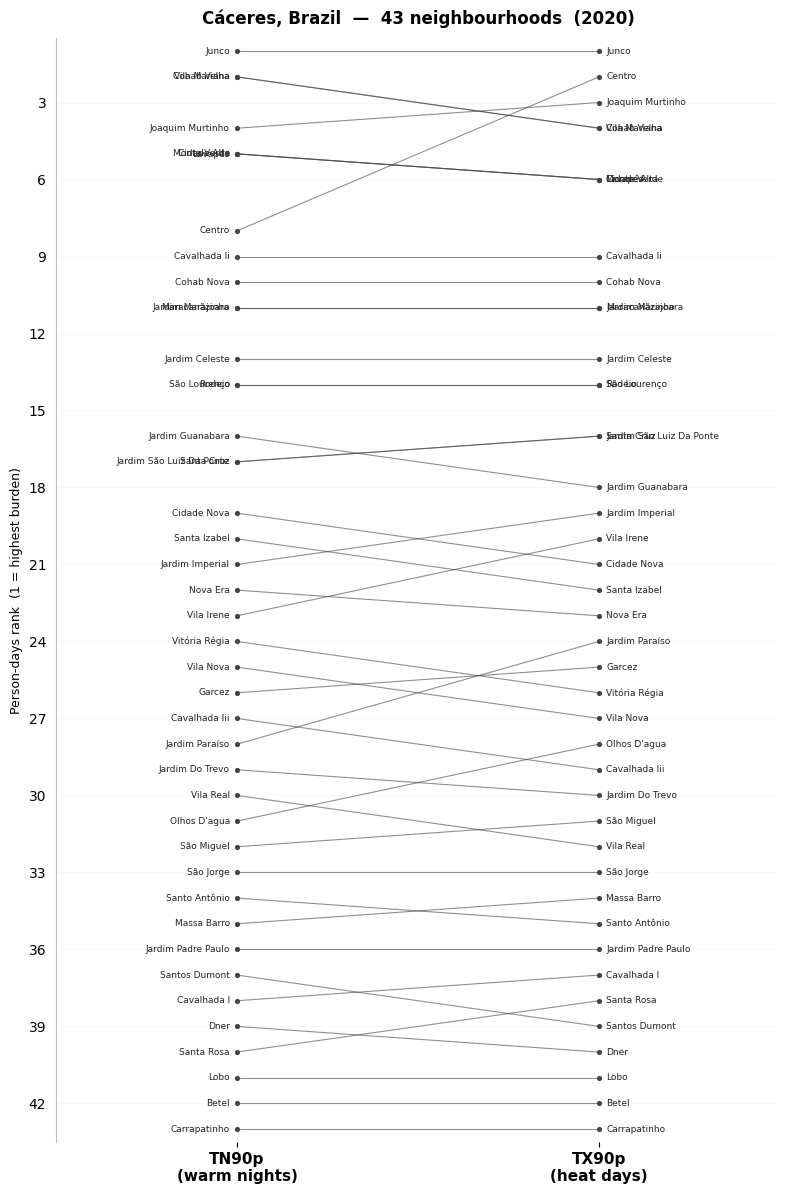

In [21]:
for c in CITY_KEYS:
    df    = tables[c].copy().sort_values('rank_tn90p_pd').reset_index(drop=True)
    n     = len(df)
    label = CITIES[c]['label']

    fig_h = max(8, n * 0.28)
    fig, ax = plt.subplots(figsize=(8, fig_h))

    for _, row in df.iterrows():
        ax.plot([0, 1], [row['rank_tn90p_pd'], row['rank_tx90p_pd']],
                color='#444444', linewidth=0.8, alpha=0.6, solid_capstyle='round')
        ax.scatter([0], [row['rank_tn90p_pd']], color='#444444', s=14, zorder=4, linewidths=0)
        ax.scatter([1], [row['rank_tx90p_pd']], color='#444444', s=14, zorder=4, linewidths=0)

    # Label every neighbourhood on both sides
    for _, row in df.iterrows():
        ax.text(-0.02, row['rank_tn90p_pd'], row['name'],
                ha='right', va='center', fontsize=6.5, color='#222222')
        ax.text(1.02, row['rank_tx90p_pd'], row['name'],
                ha='left',  va='center', fontsize=6.5, color='#222222')

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(n + 0.5, 0.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['TN90p\n(warm nights)', 'TX90p\n(heat days)'],
                       fontsize=11, fontweight='bold')
    ax.set_ylabel('Person-days rank  (1 = highest burden)', fontsize=9)
    ax.set_title(f'{label}  —  {n} neighbourhoods  ({DIAG_YEAR})',
                 fontsize=12, fontweight='bold', pad=10)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=min(n, 20)))

    for spine in ['top', 'bottom', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_alpha(0.25)
    ax.tick_params(left=False)
    ax.grid(axis='y', alpha=0.1, linewidth=0.5)

    plt.tight_layout()
    plt.show()

In [22]:
# ---- Threshold summary stats: mean, std, CV, min, max ----------------------
print(f"{'City':<12} {'Metric':<8} {'Mean (°C)':>10} {'Std (°C)':>9} {'CV (%)':>8} {'Min (°C)':>9} {'Max (°C)':>9}")
print("-" * 65)

for label, key in zip(['Salvador', 'Teresina', 'Caceres'], CITY_KEYS):
    for metric, thresh in [('TX90p', thresh_tx[key]), ('TN90p', thresh_tn[key])]:
        da = thresh.sel(percentile=90) if 'percentile' in thresh.dims else thresh
        # mean over dayofyear per pixel, then summarise spatially
        per_pixel = da.mean(dim='dayofyear')
        vals = per_pixel.values.flatten()
        vals = vals[np.isfinite(vals)]
        mean, std = float(np.mean(vals)), float(np.std(vals))
        cv = 100 * std / mean
        print(f"{label:<12} {metric:<8} {mean:>10.2f} {std:>9.2f} {cv:>8.2f} {float(vals.min()):>9.2f} {float(vals.max()):>9.2f}")
    print()


City         Metric    Mean (°C)  Std (°C)   CV (%)  Min (°C)  Max (°C)
-----------------------------------------------------------------
Salvador     TX90p         32.90      1.34     4.07     31.80     37.37
Salvador     TN90p         23.64      0.27     1.13     22.77     24.73

Teresina     TX90p         35.90      0.15     0.43     35.58     36.90
Teresina     TN90p         24.38      0.26     1.08     23.76     25.36

Caceres      TX90p         35.37      0.33     0.93     34.03     36.14
Caceres      TN90p         23.06      0.39     1.68     21.32     23.80



In [25]:
# ---- TX90p and TN90p threshold summary: mean and spatial CV -----------------
# Collapse dayofyear first (per-pixel annual mean), then compute spatial CV.
# This isolates spatial variation from seasonal variation in the threshold.

def thresh_stats(da, percentile):
    """Per-pixel annual mean threshold → spatial mean and CV."""
    da_p = da.sel(percentile=percentile) if 'percentile' in da.dims else da
    per_pixel = da_p.mean(dim='dayofyear')          # (lat, lon)
    vals = per_pixel.values.flatten()
    vals = vals[np.isfinite(vals)]
    mean = float(np.mean(vals))
    cv   = float(100 * np.std(vals) / mean)
    return mean, cv

rows = []
for c in CITY_KEYS:
    label = CITIES[c]['label']
    row = {'City': label}
    for p in [90, 95, 99]:
        if 'percentile' in thresh_tx[c].dims and p in thresh_tx[c].percentile.values:
            m, cv = thresh_stats(thresh_tx[c], p)
            row[f'TX P{p} (°C)']   = m
            row[f'TX P{p} CV (%)'] = cv
        if 'percentile' in thresh_tn[c].dims and p in thresh_tn[c].percentile.values:
            m, cv = thresh_stats(thresh_tn[c], p)
            row[f'TN P{p} (°C)']   = m
            row[f'TN P{p} CV (%)'] = cv
    rows.append(row)

df_summary = pd.DataFrame(rows).set_index('City')

email_cols = [c for c in ['TX P90 (°C)', 'TX P90 CV (%)', 'TN P90 (°C)', 'TN P90 CV (%)'] if c in df_summary.columns]
print('Email table — P90 thresholds and spatial CV')
display(df_summary[email_cols].style.format('{:.2f}').set_table_styles(table_styles))

print()
print('Full table — all available percentiles')
display(df_summary.style.format('{:.2f}').set_table_styles(table_styles))


Email table — P90 thresholds and spatial CV


,TX P90 (°C),TX P90 CV (%),TN P90 (°C),TN P90 CV (%)
City,,,,
"Salvador, Brazil",32.90,4.07,23.64,1.13
"Teresina, Brazil",35.90,0.43,24.38,1.08
"Cáceres, Brazil",35.37,0.93,23.06,1.68



Full table — all available percentiles


,TX P90 (°C),TX P90 CV (%),TN P90 (°C),TN P90 CV (%),TX P95 (°C),TX P95 CV (%),TN P95 (°C),TN P95 CV (%)
City,,,,,,,,
"Salvador, Brazil",32.90,4.07,23.64,1.13,33.76,7.57,24.24,1.39
"Teresina, Brazil",35.90,0.43,24.38,1.08,36.96,0.39,24.73,1.06
"Cáceres, Brazil",35.37,0.93,23.06,1.68,36.53,0.89,23.59,1.70
